In [90]:
# pipenv install pandas seaborn scikit-learn plotly matplotlib ipykernel ipywidgets scipy optuna streamlit nbformat

# EDA and Data Visualization
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt 

# ML
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
import numpy as np

import optuna

# EDA

## Load Dataset

In [91]:
df_notebook = pd.read_csv('./datasets/notebooks_dataset.csv')
df_notebook.info()

<class 'pandas.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     991 non-null    int64  
 1   brand                     991 non-null    str    
 2   model                     991 non-null    str    
 3   price                     991 non-null    float64
 4   rating                    991 non-null    int64  
 5   processor_brand           991 non-null    str    
 6   processor_tier            991 non-null    str    
 7   num_cores                 991 non-null    int64  
 8   num_threads               991 non-null    int64  
 9   ram_memory                991 non-null    int64  
 10  primary_storage_type      991 non-null    str    
 11  primary_storage_capacity  991 non-null    int64  
 12  gpu_brand                 991 non-null    str    
 13  gpu_type                  991 non-null    str    
 14  is_touch_screen      

In [92]:
df_notebook.head(10)

,index,brand,model,price,rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,os,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,287.72,63,intel,core i3,2,4,8,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,431.64,67,intel,core i7,4,8,16,SSD,1024,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,612.86,73,amd,ryzen 5,6,12,8,SSD,512,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,479.62,62,intel,core i5,12,16,8,SSD,512,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,342.77,62,amd,ryzen 3,4,8,8,SSD,512,amd,integrated,False,15.6,1920,1080,windows,1
5,6,apple,Apple MacBook Air 2020 MGND3HN Laptop (Apple M...,851.41,45,apple,m1,8,8,8,SSD,256,apple,apple,False,13.3,2560,1600,mac,1
6,7,infinix,Infinix INBook Y2 Plus Laptop (11th Gen Core i...,419.65,56,intel,core i5,4,8,16,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
7,8,asus,Asus TUF Gaming F15 FX506HF-HN024W Gaming Lapt...,599.55,70,intel,core i5,6,12,8,SSD,512,nvidia,dedicated,False,15.6,1920,1080,windows,1
8,9,hp,HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...,443.64,60,intel,core i3,6,8,8,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
9,10,infinix,Infinix Zerobook 2023 Laptop (13th Gen Core i9...,719.48,71,intel,core i9,14,20,32,SSD,1024,intel,integrated,False,15.6,1920,1080,windows,1


## Adjusting some columns

In [93]:
df_notebook.describe()

,index,price,rating,num_cores,num_threads,ram_memory,primary_storage_capacity,display_size,resolution_width,resolution_height
count,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000
mean,505.860747,926.687487,63.931382,8.128153,12.191726,13.047427,610.938446,15.171241,2003.503532,1181.227043
std,287.899458,688.239764,10.190575,4.215499,5.585115,5.591188,266.927666,0.938089,361.965292,263.884019
min,1.000000,117.540000,24.000000,2.000000,0.000000,2.000000,32.000000,10.100000,1080.000000,768.000000
25%,258.500000,522.850000,58.000000,6.000000,8.000000,8.000000,512.000000,14.000000,1920.000000,1080.000000
50%,507.000000,742.390000,64.000000,8.000000,12.000000,16.000000,512.000000,15.600000,1920.000000,1080.000000
75%,754.500000,1070.350000,71.000000,10.000000,16.000000,16.000000,512.000000,15.600000,1920.000000,1200.000000
max,1002.000000,5450.880000,89.000000,24.000000,32.000000,36.000000,2048.000000,18.000000,3840.000000,2560.000000


In [94]:
# Checking the feature year_of_warranty
df_notebook['year_of_warranty'].unique()

<ArrowStringArray>
['1', '2', 'No information', '3']
Length: 4, dtype: str

In [95]:
# Adjusting the feature
df_notebook['year_of_warranty'] = df_notebook['year_of_warranty'].replace('No information', "1")
df_notebook['year_of_warranty'] = df_notebook['year_of_warranty'].astype(int)

df_notebook['year_of_warranty'].unique()

array([1, 2, 3])

In [96]:
# Transforming boolean feature in int (is_touch_screen)
df_notebook['is_touch_screen'] = df_notebook['is_touch_screen'].astype(int)
df_notebook['is_touch_screen'].unique()

array([0, 1])

## Visualizing the data

In [97]:
percentual_brand = df_notebook.value_counts('brand') / len(df_notebook) * 100

px.bar(percentual_brand, color=percentual_brand.index)

In [98]:
# processor_brand percentual distribution
percentual_processor_brand = df_notebook.value_counts('processor_brand') / len(df_notebook) * 100

px.bar(percentual_processor_brand, color=percentual_processor_brand.index)

<Axes: xlabel='price', ylabel='Count'>

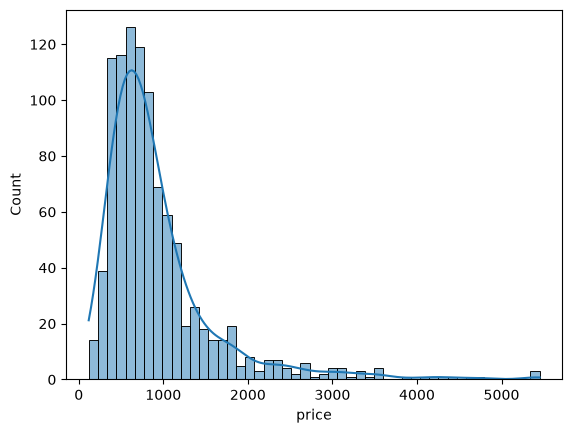

In [99]:
# Price Distribution
sns.histplot(df_notebook['price'], kde=True)

<Axes: xlabel='rating', ylabel='Count'>

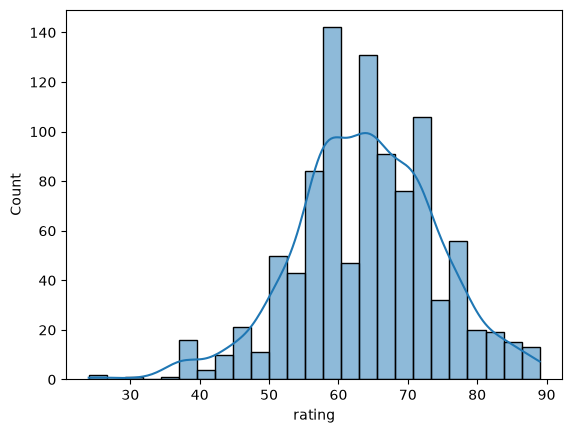

In [100]:
# Rating distribution
sns.histplot(df_notebook['rating'], kde=True)

In [101]:
# Distribution Price X Brand
px.box(df_notebook, x='price', y='brand', color='brand', orientation='h')

In [102]:
# Distribution Rating X Brand
px.box(df_notebook, x='rating', y='brand', color='brand', orientation='h')

In [103]:
# Scatterplot Price X Rating
px.scatter(df_notebook, x='price', y='rating', color='brand')

# Model Training

In [104]:
# Selecting columns for clusterization
X = df_notebook.copy()

# Removing useless columns
X.drop(columns=['index', 'model'], inplace=True)

In [105]:
numeric_features = ['price', 'rating', 'num_cores', 'num_threads', 'ram_memory', 'primary_storage_capacity', 'display_size', 'resolution_width', 'resolution_height']
categorical_features = ['brand', 'processor_brand', 'gpu_brand', 'gpu_type', 'os']

In [106]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

In [108]:
# Transforming the data
X_transformed = preprocessor.fit_transform(X)
X_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13874 stored elements and shape (991, 54)>

## Agglomerative Clustering

In [109]:
def agg_clustering_objective(trial):
    # Defining the Hyperparams to be tuned
    n_clusters = trial.suggest_int('n_clusters', 10, 150)
    # Linkage = A criterion for determining the distance between two sets to form clusters
    # Ward - Variance | Average - Mean | Complete - Max | Single - Min
    linkage = trial.suggest_categorical('linkage', ['ward', 'average', 'complete', 'single'])

    # Instance the model
    hierarchial_model = AgglomerativeClustering(linkage=linkage, n_clusters=n_clusters)

    # Train the model and execute the prediction
    y = hierarchial_model.fit_predict(X_transformed.toarray())

    # Calculate the Silhouette Score
    silhouette_avg = silhouette_score(X_transformed, y)

    return silhouette_avg

In [110]:
# Creating a optuna study
search_space_agg = {'n_clusters': range(10, 151), 'linkage': ['ward', 'average', 'complete', 'single']}
sampler_agg = optuna.samplers.GridSampler(search_space=search_space_agg)

agg_study = optuna.create_study(direction='maximize', sampler=sampler_agg)

[I 2026-06-17 14:27:20,941] A new study created in memory with name: no-name-60d86ead-330c-47d0-a181-e5ced8dc66f6


In [111]:
agg_study.optimize(agg_clustering_objective, n_trials=564)

[I 2026-06-17 14:27:20,981] Trial 0 finished with value: 0.2234907963314824 and parameters: {'n_clusters': 108, 'linkage': 'average'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-06-17 14:27:21,013] Trial 1 finished with value: 0.17524794730527618 and parameters: {'n_clusters': 44, 'linkage': 'complete'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-06-17 14:27:21,043] Trial 2 finished with value: 0.18192511775951023 and parameters: {'n_clusters': 57, 'linkage': 'average'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-06-17 14:27:21,073] Trial 3 finished with value: 0.17426651499876017 and parameters: {'n_clusters': 46, 'linkage': 'complete'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-06-17 14:27:21,104] Trial 4 finished with value: 0.22831449937222206 and parameters: {'n_clusters': 140, 'linkage': 'complete'}. Best is trial 4 with value: 0.22831449937222206.
[I 2026-06-17 14:27:21,136] Trial 5 finished with value: 0.2354443546476447 and 

In [112]:
# Show the best optuna config Agglomerative
best_params_agg = agg_study.best_params
print(f'Clusters amount: {best_params_agg['n_clusters']}')
print(f'Linkage: {best_params_agg['linkage']}')
print(f'Silhouett Score: {agg_study.best_value}')

Clusters amount: 149
Linkage: ward
Silhouett Score: 0.32745480721431686


## Divisive Clustering

In [113]:
def divisive_clustering_objective(trial):
    # Defining the Hyperparams to be tuned
    n_clusters = trial.suggest_int('n_clusters', 10, 150)

    # Instance the model
    hierarchial_model = BisectingKMeans( n_clusters=n_clusters)

    # Train the model and execute the prediction
    y = hierarchial_model.fit_predict(X_transformed.toarray())

    # Calculate the Silhouette Score
    silhouette_avg = silhouette_score(X_transformed, y)

    return silhouette_avg

In [114]:
# Creating a optuna study
search_space_div = {'n_clusters': range(10, 151)}
sampler_div = optuna.samplers.GridSampler(search_space=search_space_div)

div_study = optuna.create_study(direction='maximize', sampler=sampler_div)

[I 2026-06-17 14:28:23,792] A new study created in memory with name: no-name-b5addbbf-040d-445b-951b-4fa0f76f6760


In [115]:
div_study.optimize(divisive_clustering_objective, n_trials=140)

[I 2026-06-17 14:28:23,916] Trial 0 finished with value: 0.15838410025117247 and parameters: {'n_clusters': 55}. Best is trial 0 with value: 0.15838410025117247.
[I 2026-06-17 14:28:24,057] Trial 1 finished with value: 0.16633549708270803 and parameters: {'n_clusters': 70}. Best is trial 1 with value: 0.16633549708270803.
[I 2026-06-17 14:28:24,110] Trial 2 finished with value: 0.14747367543315068 and parameters: {'n_clusters': 17}. Best is trial 1 with value: 0.16633549708270803.
[I 2026-06-17 14:28:24,236] Trial 3 finished with value: 0.16890889842850879 and parameters: {'n_clusters': 61}. Best is trial 3 with value: 0.16890889842850879.
[I 2026-06-17 14:28:24,382] Trial 4 finished with value: 0.1465266399118844 and parameters: {'n_clusters': 76}. Best is trial 3 with value: 0.16890889842850879.
[I 2026-06-17 14:28:24,469] Trial 5 finished with value: 0.15673025028222032 and parameters: {'n_clusters': 37}. Best is trial 3 with value: 0.16890889842850879.
[I 2026-06-17 14:28:24,625] T

In [116]:
# Show the best optuna config Divisive
best_params_div = div_study.best_params
print(f'Clusters amount: {best_params_div['n_clusters']}')
print(f'Silhouett Score: {div_study.best_value}')

Clusters amount: 126
Silhouett Score: 0.208478943007759


## Creating the model with the best params

In [117]:
best_model = AgglomerativeClustering(
                                        n_clusters=best_params_agg['n_clusters'], 
                                        linkage=best_params_agg['linkage']
                                    )

In [118]:
# Train the model
best_model.fit(X_transformed.toarray())

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",149
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sam

In [119]:
# Verify the silhouette Score
best_score = silhouette_score(X_transformed, best_model.labels_)
best_score

0.32745480721431686

In [120]:
# Create the Cluster column on the dataframe
df_notebook['cluster'] = best_model.labels_
df_notebook.head(10)

,index,brand,model,price,rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,primary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,os,year_of_warranty,cluster
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,287.72,63,intel,core i3,2,4,8,...,512,intel,integrated,0,15.6,1920,1080,windows,1,73
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,431.64,67,intel,core i7,4,8,16,...,1024,intel,integrated,0,15.6,1920,1080,windows,1,44
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,612.86,73,amd,ryzen 5,6,12,8,...,512,amd,dedicated,0,15.6,1920,1080,windows,1,28
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,479.62,62,intel,core i5,12,16,8,...,512,intel,integrated,0,14.0,1920,1080,windows,1,53
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,342.77,62,amd,ryzen 3,4,8,8,...,512,amd,integrated,0,15.6,1920,1080,windows,1,14
5,6,apple,Apple MacBook Air 2020 MGND3HN Laptop (Apple M...,851.41,45,apple,m1,8,8,8,...,256,apple,apple,0,13.3,2560,1600,mac,1,113
6,7,infinix,Infinix INBook Y2 Plus Laptop (11th Gen Core i...,419.65,56,intel,core i5,4,8,16,...,512,intel,integrated,0,15.6,1920,1080,windows,1,4
7,8,asus,Asus TUF Gaming F15 FX506HF-HN024W Gaming Lapt...,599.55,70,intel,core i5,6,12,8,...,512,nvidia,dedicated,0,15.6,1920,1080,windows,1,19
8,9,hp,HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...,443.64,60,intel,core i3,6,8,8,...,512,intel,integrated,0,15.6,1920,1080,windows,1,95
9,10,infinix,Infinix Zerobook 2023 Laptop (13th Gen Core i9...,719.48,71,intel,core i9,14,20,32,...,1024,intel,integrated,0,15.6,1920,1080,windows,1,83


## Result analysis

In [121]:
# Optuna Trials Chart
fig = optuna.visualization.plot_optimization_history(agg_study)
fig.show()

In [122]:
# Train the model with scipy
model_de = linkage(X_transformed.toarray(), method=best_params_agg['linkage'], optimal_ordering=True)

Text(0, 0.5, 'Distance')

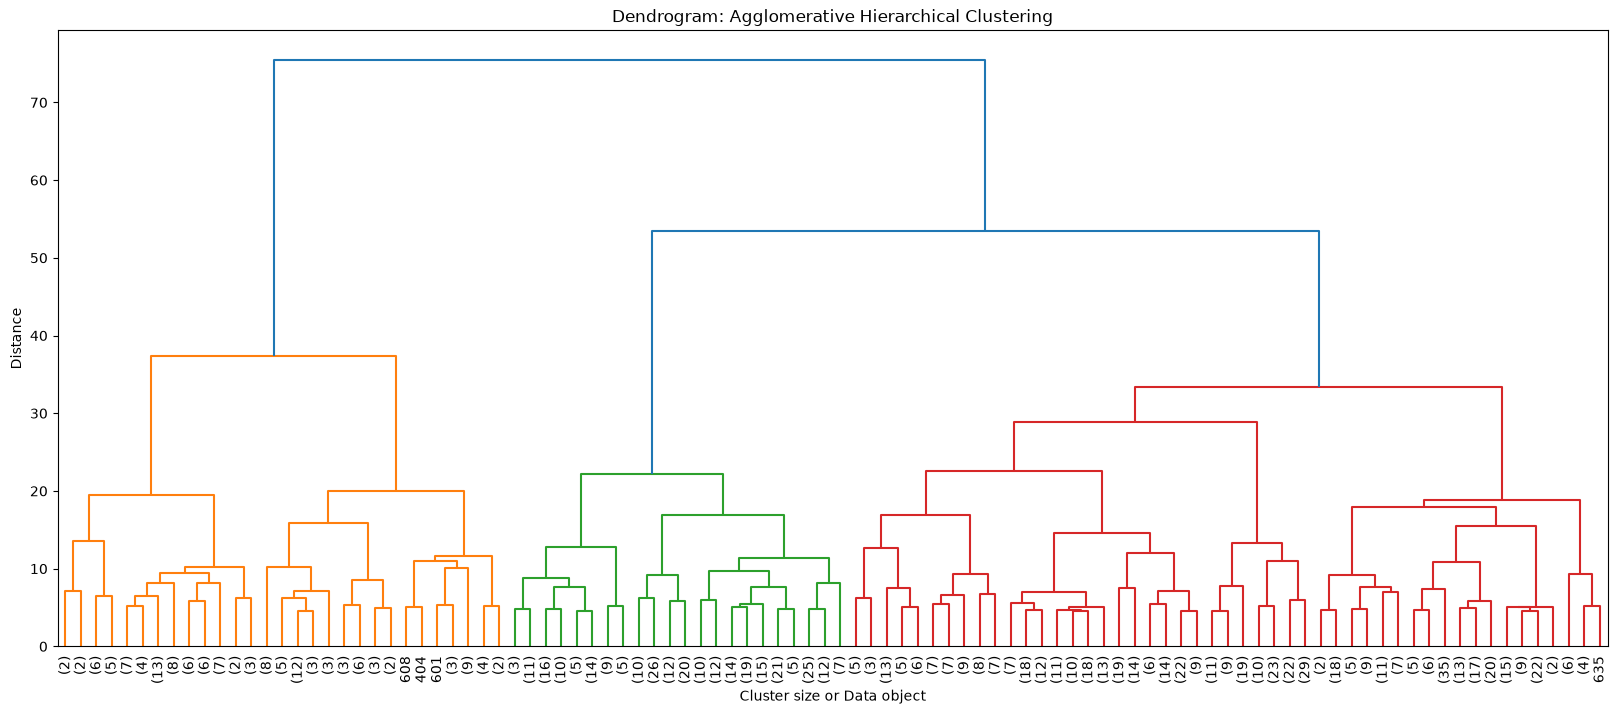

In [123]:
# Show the Dendrogram
plt.figure(figsize=(20, 8))
dendrogram(model_de, truncate_mode='lastp', p=100, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrogram: Agglomerative Hierarchical Clustering")
plt.xlabel("Cluster size or Data object")
plt.ylabel("Distance")

In [124]:
# Cut the dendogram
scipy_clusters = cut_tree(model_de, height=32)
len(np.unique(scipy_clusters))

5

In [125]:
# Crossing Brand X Price by cluster
px.scatter(df_notebook, x='brand', y='price', color='cluster')

In [126]:
# Crossing Cluster X Price by Brand
px.scatter(df_notebook, x='cluster', y='price', color='brand')

In [127]:
# Crossing Brand X Rating by cluster
px.scatter(df_notebook, x='brand', y='rating', color='cluster')

In [128]:
percentual_cluster = df_notebook.value_counts('cluster') / len(df_notebook) * 100

px.bar(percentual_cluster, color=percentual_cluster.index)

In [129]:
cluster_count = df_notebook.value_counts('cluster')

px.bar(cluster_count, color=cluster_count.index)

# Saving the model

In [130]:
import joblib

joblib.dump(best_model, './notebook_clusterization_model.pkl')
joblib.dump(best_model, './notebook_clusterization_preprocessor.pkl')

['./notebook_clusterization_preprocessor.pkl']

In [131]:
df_notebook.to_csv('./output/notebook_clusterization.csv', index=False)